# Mountain NER — Dataset Creation

Building a labeled dataset for detecting mountain names in text. Plan: gazetteer of real mountains → generate varied sentences about them → add hard negatives (other proper nouns) → auto-label with BIO tags → clean up and split → save.


## 1. Mountain list + heights

In [9]:
import re
import json
import random
from collections import Counter

random.seed(42)

MOUNTAINS = [
    "Mount Everest", "K2", "Kangchenjunga", "Lhotse", "Makalu", "Cho Oyu", "Dhaulagiri",
    "Manaslu", "Nanga Parbat", "Annapurna", "Gasherbrum I", "Broad Peak",
    "Mont Blanc", "Matterhorn", "Eiger", "Jungfrau", "Monte Rosa", "Grossglockner",
    "Mount Elbrus", "Kilimanjaro", "Mount Kenya", "Mount Meru", "Ras Dashen",
    "Denali", "Mount Rainier", "Mount Whitney", "Mount Shasta", "Longs Peak", "Pikes Peak",
    "Aconcagua", "Mount Fuji", "Ben Nevis", "Mount Cook", "Table Mountain",
    "Mount Olympus", "Mount Kosciuszko", "Mount Ararat", "Popocatepetl", "Mount Vesuvius",
    "Mauna Kea", "Mount Kailash", "Mount Sinai", "Mount Fitz Roy",
]

HEIGHTS_M = {
    "Mount Everest": 8849, "K2": 8611, "Kangchenjunga": 8586, "Lhotse": 8516,
    "Makalu": 8485, "Cho Oyu": 8188, "Dhaulagiri": 8167, "Manaslu": 8163,
    "Nanga Parbat": 8126, "Annapurna": 8091, "Gasherbrum I": 8080, "Broad Peak": 8051,
    "Mont Blanc": 4808, "Matterhorn": 4478, "Eiger": 3967, "Jungfrau": 4158,
    "Monte Rosa": 4634, "Grossglockner": 3798, "Mount Elbrus": 5642, "Kilimanjaro": 5895,
    "Mount Kenya": 5199, "Mount Meru": 4562, "Ras Dashen": 4550, "Denali": 6190,
    "Mount Rainier": 4392, "Mount Whitney": 4421, "Mount Shasta": 4322, "Longs Peak": 4346,
    "Pikes Peak": 4302, "Aconcagua": 6961, "Mount Fuji": 3776, "Ben Nevis": 1345,
    "Mount Cook": 3724, "Table Mountain": 1085, "Mount Olympus": 2917,
    "Mount Kosciuszko": 2228, "Mount Ararat": 5137, "Popocatepetl": 5426,
    "Mount Vesuvius": 1281, "Mauna Kea": 4207, "Mount Kailash": 6638, "Mount Sinai": 2285,
    "Mount Fitz Roy": 3405,
}

len(MOUNTAINS), len(HEIGHTS_M)


(43, 43)

For a bigger version of this, pull names from Wikidata instead of hardcoding them.

## 2. Generating sentences

Combining ~30 sentence templates with random verbs/adjectives and real height facts, so it's not just the same sentence repeated with a different name swapped in.

In [10]:
ADJECTIVES = ["majestic", "towering", "iconic", "breathtaking", "snow-capped", "remote", "legendary"]
VERBS_CLIMB = ["climb", "ascend", "scale", "summit", "conquer"]

TEMPLATES = [
    "{m} is one of the most iconic peaks in the world.",
    "Last summer, our team attempted to {verb} {m} but turned back due to weather.",
    "The documentary features stunning aerial footage of {m}.",
    "Hikers say the trail up {m} takes about five days to complete.",
    "{m} rises sharply above the surrounding valley.",
    "News reports confirmed that a group of climbers reached the summit of {m} yesterday.",
    "Many tourists visit the region just to see {m} up close.",
    "The local legend describes {m} as the home of ancient spirits.",
    "Snow covers the upper slopes of {m} for most of the year.",
    "Scientists are studying glacier retreat on {m}.",
    "During our trip, we saw both {m} and {m2} from the viewpoint.",
    "Compared to {m}, {m2} is considerably easier to {verb}.",
    "The weather near {m} can change without warning.",
    "This guidebook covers routes to {m} and nearby peaks.",
    "{m} attracts thousands of mountaineers every climbing season.",
    "Have you ever wondered what it takes to {verb} {m}?",
    "The {adj} silhouette of {m} dominates the skyline at sunset.",
    "In 1953, the first successful expedition reached the top of {m}.",
    "Local guides refuse to lead tours up {m} during the winter months.",
    "Photographers travel for days just to capture {m} at dawn.",
    "{m} was named after an early European surveyor of the region.",
    "Why do so many climbers dream of reaching the summit of {m}?",
    "Unlike {m2}, {m} requires specialized equipment and permits.",
    "The base camp for {m} sits at a surprisingly high altitude.",
    "Every year, dozens of expeditions set out to {verb} {m}.",
    "According to the park ranger, {m} is closed to visitors after October.",
    "The {adj} peak of {m} can be seen from over a hundred kilometers away.",
    "A sudden storm forced the climbers off {m} before nightfall.",
    "{m} has claimed the lives of many climbers over the decades.",
    "The indigenous people who live near {m} consider it sacred.",
]

HEIGHT_TEMPLATES = [
    "{m} stands at {height} meters above sea level.",
    "At {height} meters, {m} is one of the tallest peaks in its region.",
    "Reaching {height} meters, {m} dominates the surrounding landscape.",
]

def build_sentence_pool(mountains, heights, n_per_mountain=10):
    pool = []
    for mt in mountains:
        others = [x for x in mountains if x != mt]
        chosen = random.sample(TEMPLATES, k=min(n_per_mountain, len(TEMPLATES)))
        for t in chosen:
            kwargs = {"m": mt}
            if "{m2}" in t:
                kwargs["m2"] = random.choice(others)
            if "{verb}" in t:
                kwargs["verb"] = random.choice(VERBS_CLIMB)
            if "{adj}" in t:
                kwargs["adj"] = random.choice(ADJECTIVES)
            pool.append(t.format(**kwargs))
        if mt in heights:
            ht = random.choice(HEIGHT_TEMPLATES)
            pool.append(ht.format(m=mt, height=heights[mt]))
    return pool

raw_sentences = build_sentence_pool(MOUNTAINS, HEIGHTS_M, n_per_mountain=10)

len(raw_sentences), len(set(raw_sentences))


(473, 473)

## 3. Hard negatives

Sentences built with the same structures, but about other proper nouns (rivers, lakes, cities, people) instead of mountains. Ground truth is all `O` since none of these are in the mountain gazetteer. This teaches the model that being a capitalized multi-word phrase isn't enough on its own to be tagged as a mountain.

In [11]:
OTHER_ENTITIES = [
    "Amazon River", "Nile River", "Yangtze River", "Mississippi River", "Danube River",
    "Lake Victoria", "Lake Baikal", "Lake Superior", "Lake Titicaca",
    "Paris", "Tokyo", "Cairo", "Toronto", "Berlin", "Nairobi", "Lima", "Seoul", "Oslo",
    "Sahara Desert", "Amazon Rainforest", "Great Barrier Reef",
    "Sofia Rossi", "Carlos Mendes", "Amelia Johnson", "David Chen",
]

HARD_NEGATIVE_TEMPLATES = [
    "{e} is one of the most iconic sights in the world.",
    "Last summer, our team visited {e} during a research trip.",
    "The documentary features stunning footage of {e}.",
    "Guides say the tour around {e} takes about five days to complete.",
    "News reports confirmed unusual activity near {e} yesterday.",
    "Many tourists visit {e} every year.",
    "The local legend describes {e} as a place of great importance.",
    "Scientists are studying environmental changes around {e}.",
    "This guidebook covers {e} and nearby attractions.",
    "{e} attracts thousands of visitors every season.",
    "Photographers travel for days just to see {e}.",
    "According to the report, {e} was mentioned several times.",
]

PLAIN_NEGATIVE_SENTENCES = [
    "The meeting was rescheduled to next Tuesday.",
    "She bought a new laptop for her studies.",
    "The stock market fell sharply this morning.",
    "He enjoys reading historical novels on weekends.",
    "The recipe calls for two cups of flour and one egg.",
    "Traffic was heavy on the highway this afternoon.",
    "The new policy takes effect at the start of next month.",
    "Her flight was delayed by almost three hours.",
]

def build_hard_negatives(entities, n_per_entity=4):
    pool = []
    for e in entities:
        chosen = random.sample(HARD_NEGATIVE_TEMPLATES, k=min(n_per_entity, len(HARD_NEGATIVE_TEMPLATES)))
        for t in chosen:
            pool.append(t.format(e=e))
    return pool

hard_negatives = build_hard_negatives(OTHER_ENTITIES, n_per_entity=4)
raw_sentences.extend(hard_negatives)
raw_sentences.extend(PLAIN_NEGATIVE_SENTENCES * 3)

len(raw_sentences), len(hard_negatives)


(597, 100)

## 4. Auto-labeling (BIO tags)

We know which mountain each sentence was built around, so we can find its position in the text and convert that into token-level tags: `B-MOUNTAIN`, `I-MOUNTAIN`, `O`. Sentences about other entities naturally come out all-`O`, since those names aren't in the mountain gazetteer.

In [12]:
def bio_tag_sentence(sentence, mountain_names):
    spans = []
    for name in sorted(mountain_names, key=len, reverse=True):
        for m in re.finditer(re.escape(name), sentence):
            start, end = m.start(), m.end()
            if any(not (end <= s or start >= e) for s, e in spans):
                continue
            spans.append((start, end))
    spans.sort()

    tokens, tags = [], []
    for tok_match in re.finditer(r"\w+|[^\w\s]", sentence):
        tstart, tend = tok_match.span()
        word = tok_match.group()
        if re.match(r"^\W$", word):
            continue
        tag = "O"
        for (s, e) in spans:
            if tstart >= s and tend <= e:
                tag = "I-MOUNTAIN" if tstart > s else "B-MOUNTAIN"
                break
        tokens.append(word)
        tags.append(tag)
    return tokens, tags


labeled_dataset = []
for sentence in raw_sentences:
    tokens, tags = bio_tag_sentence(sentence, MOUNTAINS)
    labeled_dataset.append({"text": sentence, "tokens": tokens, "tags": tags})

for example in [labeled_dataset[0], labeled_dataset[-1], labeled_dataset[len(labeled_dataset)//2]]:
    print(example["text"])
    print(list(zip(example["tokens"], example["tags"])))
    print("-" * 60)


Mount Everest was named after an early European surveyor of the region.
[('Mount', 'B-MOUNTAIN'), ('Everest', 'I-MOUNTAIN'), ('was', 'O'), ('named', 'O'), ('after', 'O'), ('an', 'O'), ('early', 'O'), ('European', 'O'), ('surveyor', 'O'), ('of', 'O'), ('the', 'O'), ('region', 'O')]
------------------------------------------------------------
Her flight was delayed by almost three hours.
[('Her', 'O'), ('flight', 'O'), ('was', 'O'), ('delayed', 'O'), ('by', 'O'), ('almost', 'O'), ('three', 'O'), ('hours', 'O')]
------------------------------------------------------------
The documentary features stunning aerial footage of Longs Peak.
[('The', 'O'), ('documentary', 'O'), ('features', 'O'), ('stunning', 'O'), ('aerial', 'O'), ('footage', 'O'), ('of', 'O'), ('Longs', 'B-MOUNTAIN'), ('Peak', 'I-MOUNTAIN')]
------------------------------------------------------------


## 5. Dedup + train/val/test split

In [13]:
seen = set()
deduped = []
for ex in labeled_dataset:
    if ex["text"] not in seen:
        seen.add(ex["text"])
        deduped.append(ex)

random.shuffle(deduped)
n = len(deduped)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_set = deduped[:train_end]
val_set = deduped[train_end:val_end]
test_set = deduped[val_end:]

len(deduped), len(train_set), len(val_set), len(test_set)


(581, 464, 58, 59)

## 6. Quick stats

{'B-MOUNTAIN': 514, 'I-MOUNTAIN': 343}
avg sentence length: 10.8 tokens
sentences with no entity (negatives + hard negatives): 18.6%


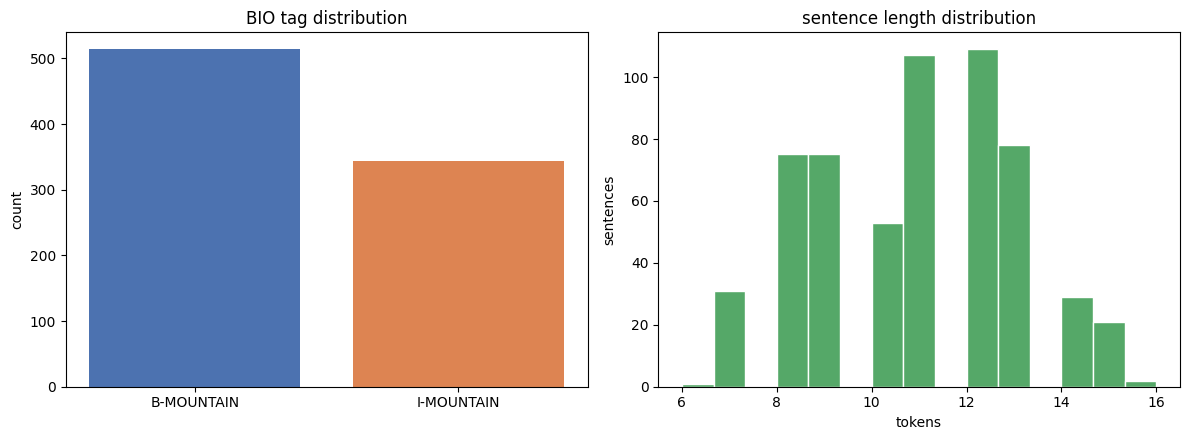

In [14]:
import matplotlib.pyplot as plt

entity_counts = Counter()
for ex in deduped:
    entity_counts.update(t for t in ex["tags"] if t != "O")

sentence_lengths = [len(ex["tokens"]) for ex in deduped]
no_entity_share = sum(1 for ex in deduped if all(t == "O" for t in ex["tags"])) / len(deduped)

print(dict(entity_counts))
print(f"avg sentence length: {sum(sentence_lengths)/len(sentence_lengths):.1f} tokens")
print(f"sentences with no entity (negatives + hard negatives): {no_entity_share:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(entity_counts.keys(), entity_counts.values(), color=["#4C72B0", "#DD8452"])
axes[0].set_title("BIO tag distribution")
axes[0].set_ylabel("count")

axes[1].hist(sentence_lengths, bins=15, color="#55A868", edgecolor="white")
axes[1].set_title("sentence length distribution")
axes[1].set_xlabel("tokens")
axes[1].set_ylabel("sentences")

plt.tight_layout()
plt.show()


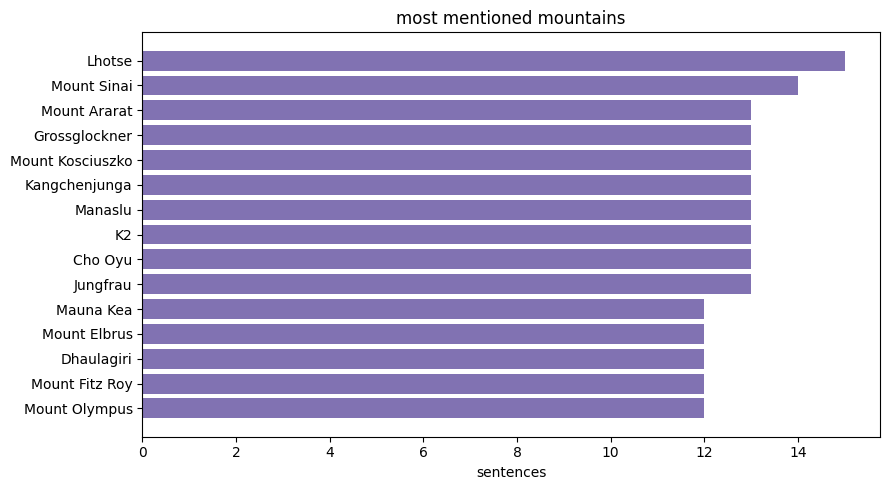

In [15]:
mountain_mention_counts = Counter()
for ex in deduped:
    text = ex["text"]
    for name in MOUNTAINS:
        if name in text:
            mountain_mention_counts[name] += 1

top_mountains = mountain_mention_counts.most_common(15)
names, counts = zip(*top_mountains)

plt.figure(figsize=(9, 5))
plt.barh(names[::-1], counts[::-1], color="#8172B2")
plt.title("most mentioned mountains")
plt.xlabel("sentences")
plt.tight_layout()
plt.show()


## 7. Save

In [16]:
import os

OUTPUT_DIR = "dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_jsonl(data, path):
    with open(path, "w", encoding="utf-8") as f:
        for ex in data:
            f.write(json.dumps(ex, ensure_ascii=False) + "\n")

save_jsonl(train_set, f"{OUTPUT_DIR}/train.jsonl")
save_jsonl(val_set, f"{OUTPUT_DIR}/val.jsonl")
save_jsonl(test_set, f"{OUTPUT_DIR}/test.jsonl")

def save_conll(data, path):
    with open(path, "w", encoding="utf-8") as f:
        for ex in data:
            for tok, tag in zip(ex["tokens"], ex["tags"]):
                f.write(f"{tok}\t{tag}\n")
            f.write("\n")

save_conll(deduped, f"{OUTPUT_DIR}/dataset_conll.txt")

sorted(os.listdir(OUTPUT_DIR))


['dataset_conll.txt', 'test.jsonl', 'train.jsonl', 'val.jsonl']